In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import yfinance as yf

from dotenv import load_dotenv
import os
import sys

load_dotenv()  # carga .env
sys.path.insert(0, os.path.join(os.environ["CUANTIS_ROOT"], "src"))

In [2]:
from cuantis_utils.Model1HypothesisTester import Model1HypothesisTester, DEFAULT_DISTRIBUTIONS

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

In [4]:
tickets = "CVX"

start_date = "2016-02-11"
end_date = "2026-02-11"

prices = yf.download(tickets, start_date, end_date)["Close"]
prices.head(2)

[*********************100%***********************]  1 of 1 completed


Ticker,CVX
Date,
2016-02-11,54.10
2016-02-12,55.69


In [7]:
dist = DEFAULT_DISTRIBUTIONS[:10]
dist

(<scipy.stats._continuous_distns.norm_gen at 0x7736787fd1f0>,
 <scipy.stats._continuous_distns.laplace_gen at 0x773678858e90>)

In [ ]:
CVX = Model1HypothesisTester(
    prices["CVX"], 
    distributions=dist)

In [9]:
CVX.get_distributions

(<scipy.stats._continuous_distns.norm_gen at 0x7736787fd1f0>,
 <scipy.stats._continuous_distns.wrapcauchy_gen at 0x7736783137a0>)

In [10]:
returns = CVX.compute_returns()
returns.head(2)

,R,r
Date,,
2016-02-12,0.03,0.03
2016-02-16,0.01,0.01


In [11]:
CVX.test_variance_equality().decision

'Varianzas iguales'

In [12]:
CVX.test_mean_difference().decision

'Medias diferentes'

In [13]:
result_dist = CVX.fit_distributions()

In [14]:
result_dist["name_best_distribution_R"]

'nct'

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'R: Histograma y PDF ajustada'}, ylabel='Frequency'>,
        <Axes: title={'center': 'r: Histograma y PDF ajustada'}, ylabel='Frequency'>],
       dtype=object))

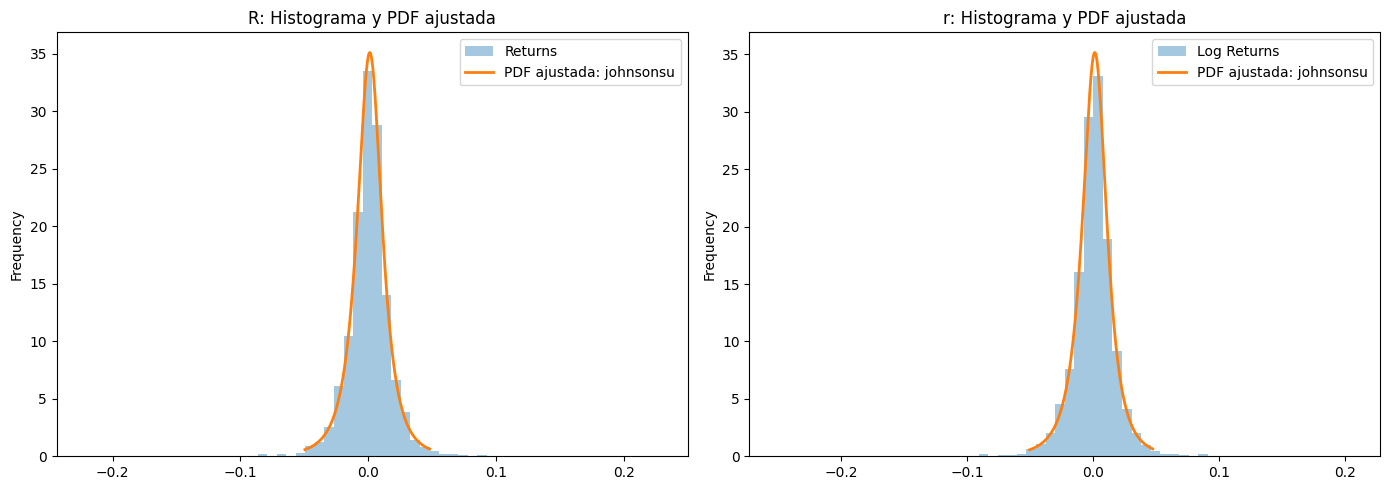

In [ ]:
CVX.plot_fitted_distributions()